In [2]:
!pip install librosa

In [3]:
import os

audio_files = [
    f for f in os.listdir('/content')
    if f.lower().endswith('.wav')
]

print("Найдено аудиофайлов:", len(audio_files))

for file in audio_files:
    print(file)

Найдено аудиофайлов: 11
killer-whale-orcinus-orca.wav
pilot-whale-globicephala-spp.wav
north-atlantic-right-whale-eubalaena-glacialis-2.wav
fin-whale-balaenoptera physalus.wav
sei-whale-balaenoptera-borealis.wav
northern-bottlenose-whale-hyperoodon-ampullatus.wav
humpback-whale-megaptera-novaeangliae.wav
minke-whale-balaenoptera-acutorostrata.wav
north-atlantic-right-whale-eubalaena-glacialis-1.wav
blue-whale-balaenoptera-musculus.wav
sperm-whale-physeter-macrocephalus.wav


File: killer-whale-orcinus-orca.wav
Duration: 53.5 seconds
Sample rate: 44100


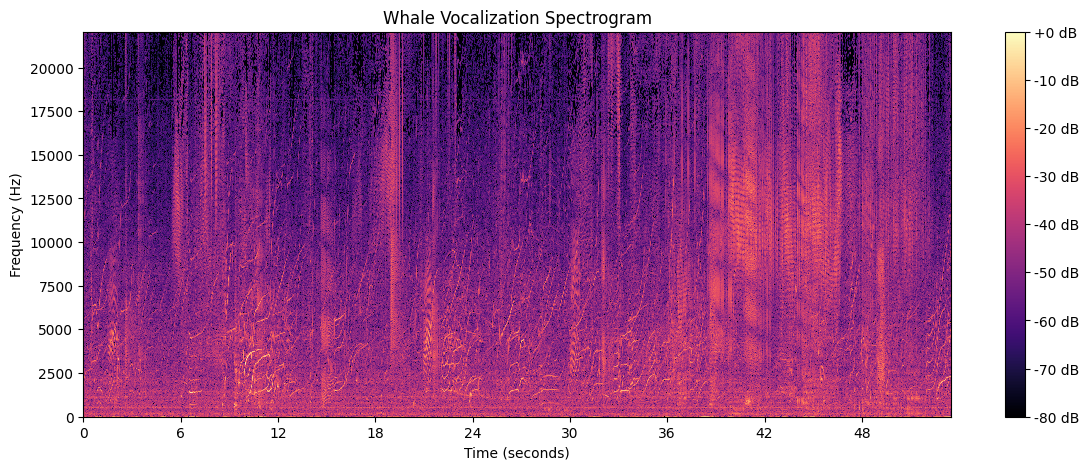

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

file_path = '/content/' + audio_files[0]

y, sr = librosa.load(file_path, sr=None)

print("File:", audio_files[0])
print("Duration:", round(len(y) / sr, 2), "seconds")
print("Sample rate:", sr)

plt.figure(figsize=(14, 5))

spectrogram = librosa.amplitude_to_db(
    np.abs(librosa.stft(y)),
    ref=np.max
)

librosa.display.specshow(
    spectrogram,
    sr=sr,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title('Whale Vocalization Spectrogram')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (Hz)')
plt.show()

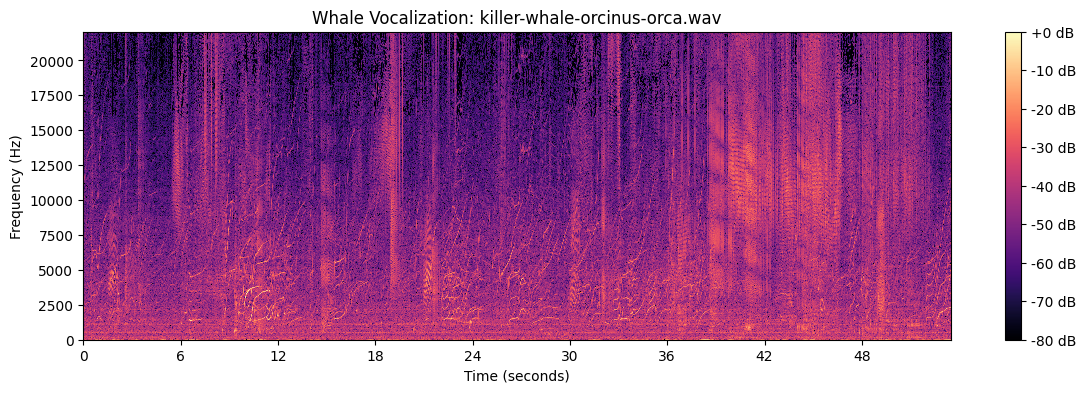

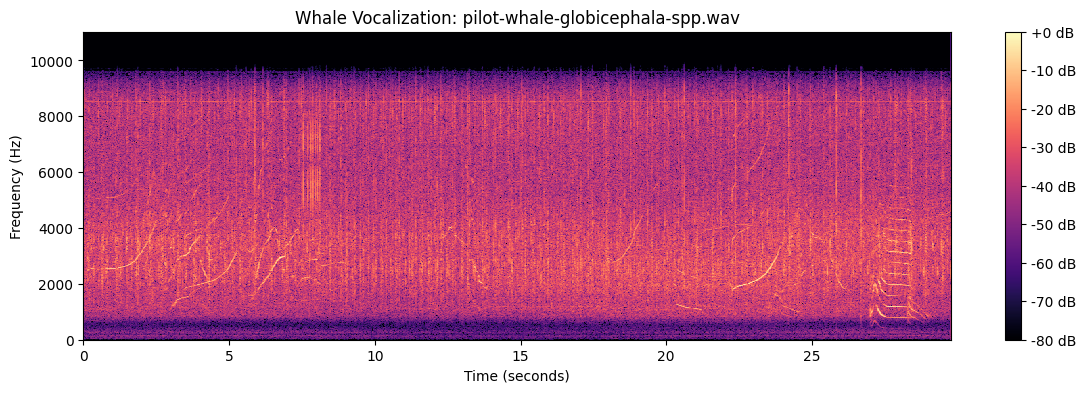

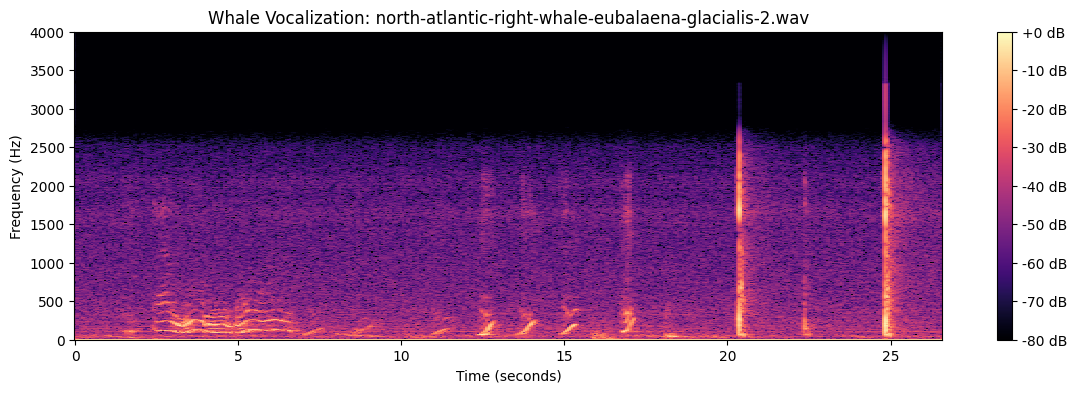

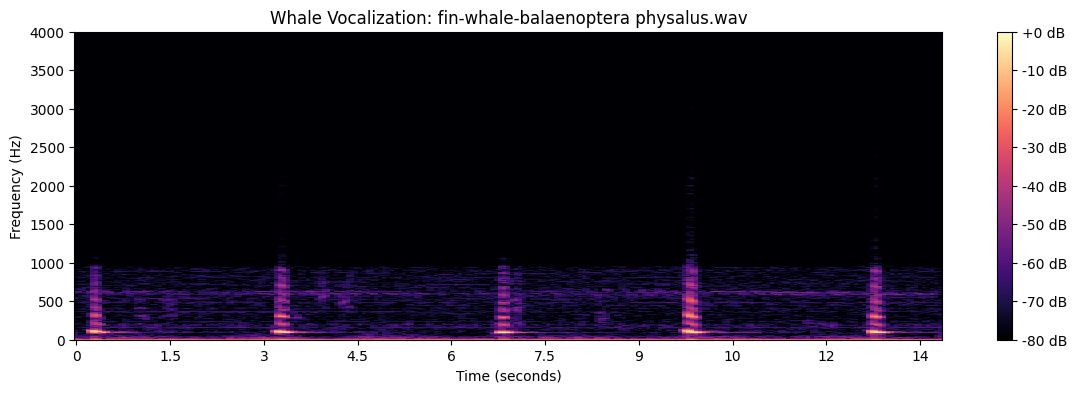

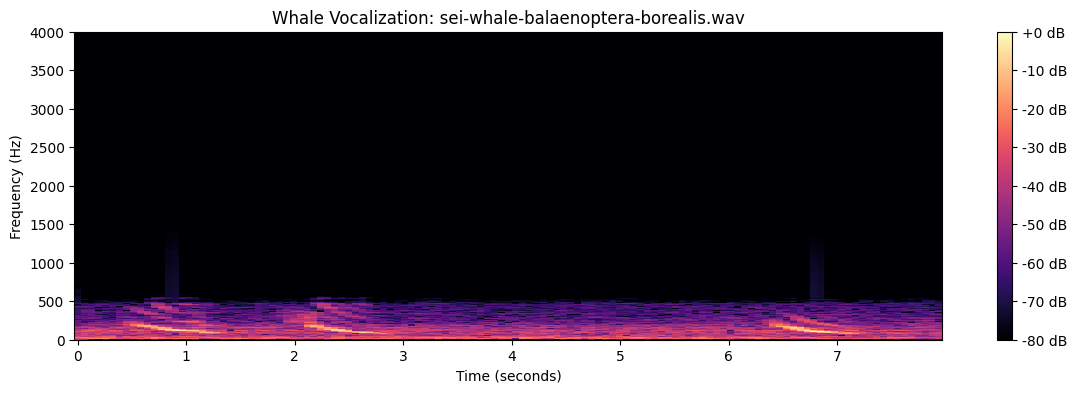

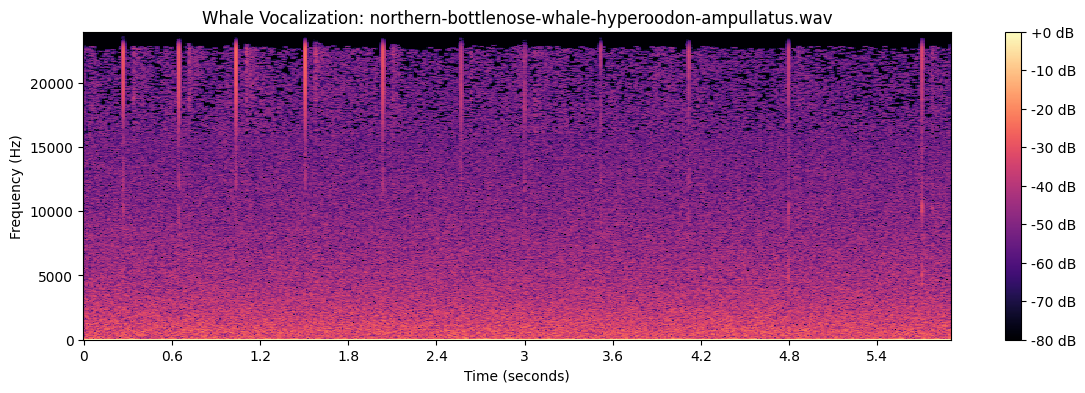

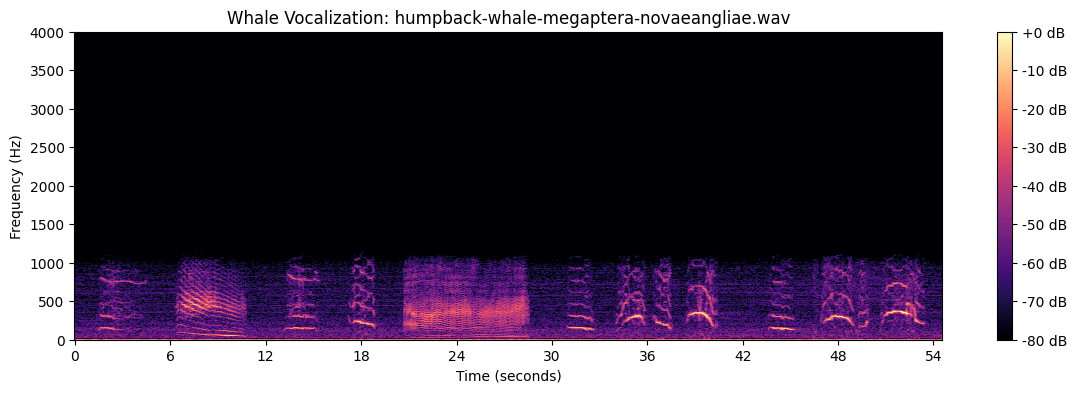

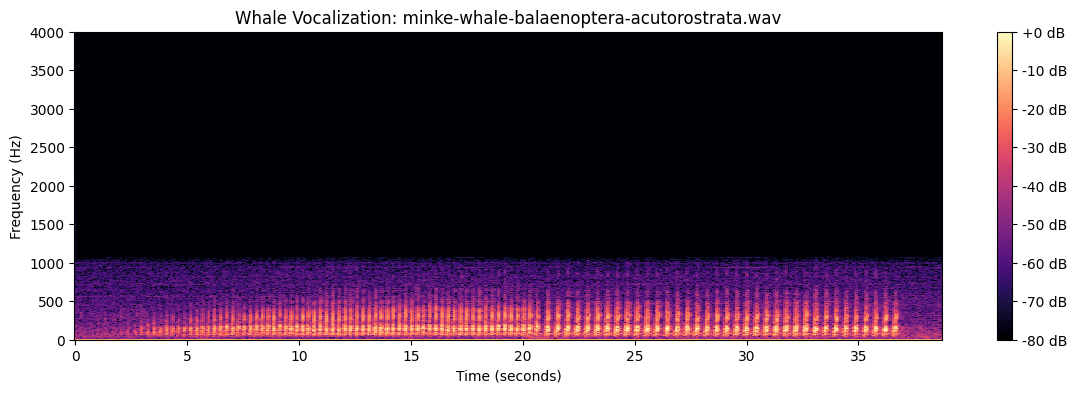

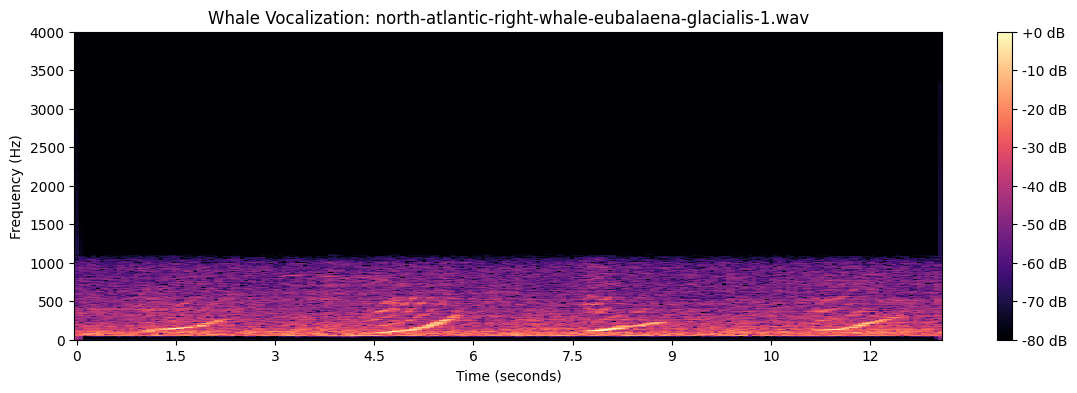

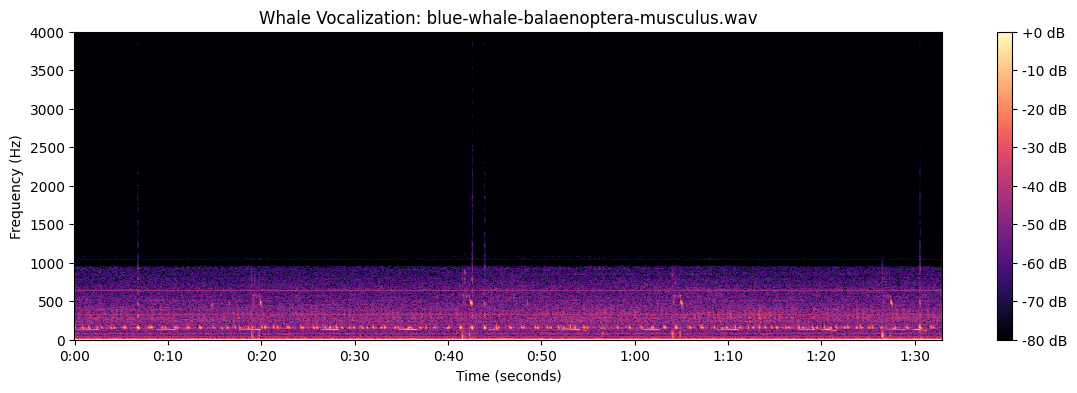

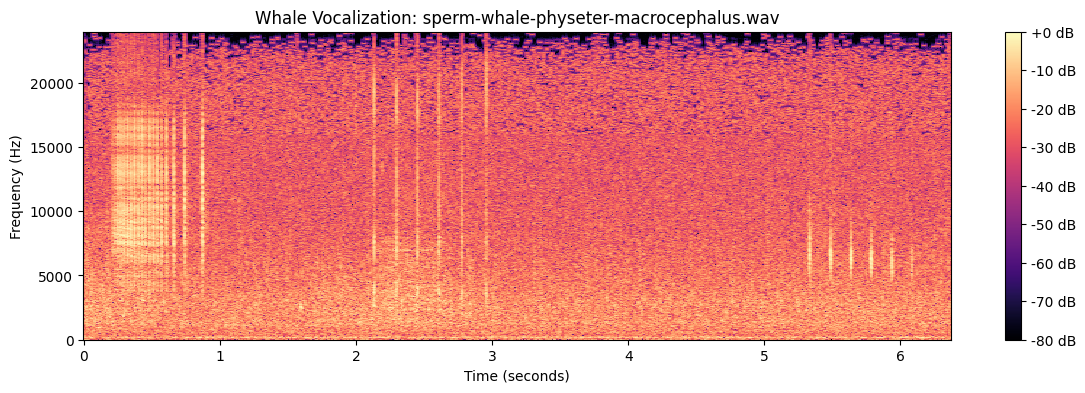

In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

for file in audio_files:

    file_path = '/content/' + file

    y, sr = librosa.load(file_path, sr=None)

    spectrogram = librosa.amplitude_to_db(
        np.abs(librosa.stft(y)),
        ref=np.max
    )

    plt.figure(figsize=(14, 4))

    librosa.display.specshow(
        spectrogram,
        sr=sr,
        x_axis='time',
        y_axis='hz'
    )

    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Whale Vocalization: {file}')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Frequency (Hz)')
    plt.show()

In [6]:
import pandas as pd
import librosa
import numpy as np

results = []

for file in audio_files:

    file_path = '/content/' + file

    y, sr = librosa.load(file_path, sr=None)

    duration = librosa.get_duration(y=y, sr=sr)

    rms = float(np.mean(
        librosa.feature.rms(y=y)
    ))

    spectral_centroid = float(np.mean(
        librosa.feature.spectral_centroid(y=y, sr=sr)
    ))

    spectral_bandwidth = float(np.mean(
        librosa.feature.spectral_bandwidth(y=y, sr=sr)
    ))

    results.append({
        'file': file,
        'duration_sec': duration,
        'rms': rms,
        'spectral_centroid_hz': spectral_centroid,
        'spectral_bandwidth_hz': spectral_bandwidth
    })

df = pd.DataFrame(results)

df

,file,duration_sec,rms,spectral_centroid_hz,spectral_bandwidth_hz
0,killer-whale-orcinus-orca.wav,53.499841,0.032999,6671.273391,5295.846447
1,pilot-whale-globicephala-spp.wav,29.775737,0.034570,4305.390013,2247.833717
2,north-atlantic-right-whale-eubalaena-glacialis...,26.604000,0.017030,524.755466,647.826085
3,fin-whale-balaenoptera physalus.wav,13.844000,0.066558,208.137041,307.751703
4,sei-whale-balaenoptera-borealis.wav,7.977000,0.127455,114.020840,116.172660
5,northern-bottlenose-whale-hyperoodon-ampullatu...,5.898958,0.018005,5214.266887,6048.604959
6,humpback-whale-megaptera-novaeangliae.wav,54.583000,0.069074,283.331053,260.756400
7,minke-whale-balaenoptera-acutorostrata.wav,38.730500,0.042588,185.989571,197.164866
8,north-atlantic-right-whale-eubalaena-glacialis...,13.086500,0.047011,249.248448,235.271673
9,blue-whale-balaenoptera-musculus.wav,92.966000,0.229368,142.680400,208.987359


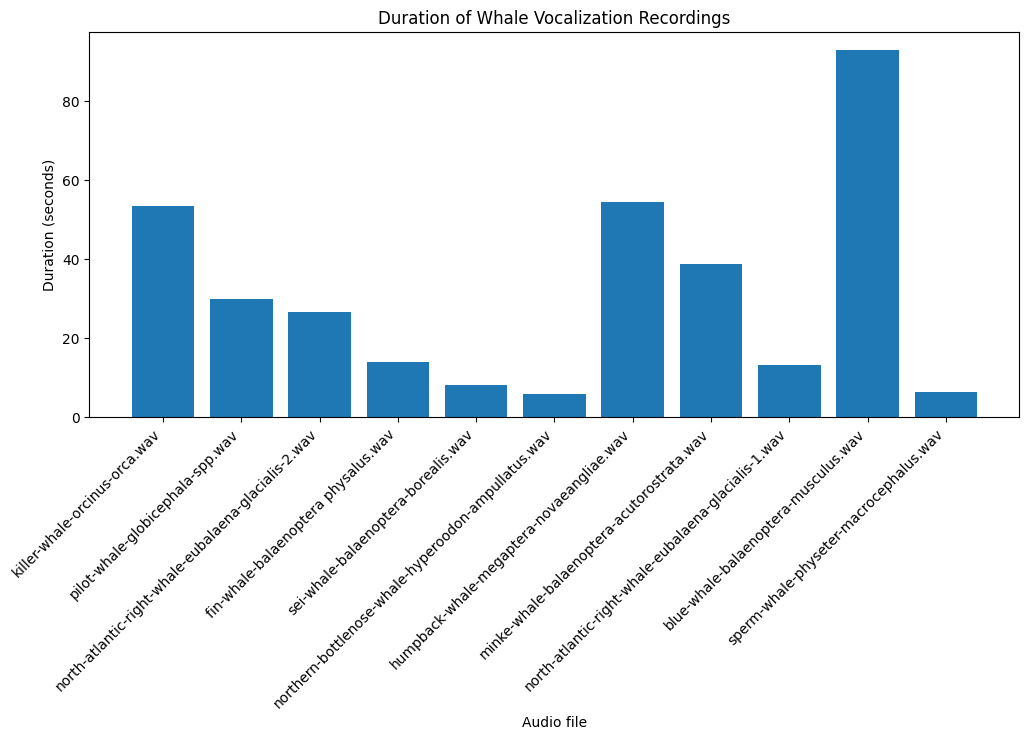

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.bar(df['file'], df['duration_sec'])

plt.title('Duration of Whale Vocalization Recordings')
plt.xlabel('Audio file')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45, ha='right')

plt.show()

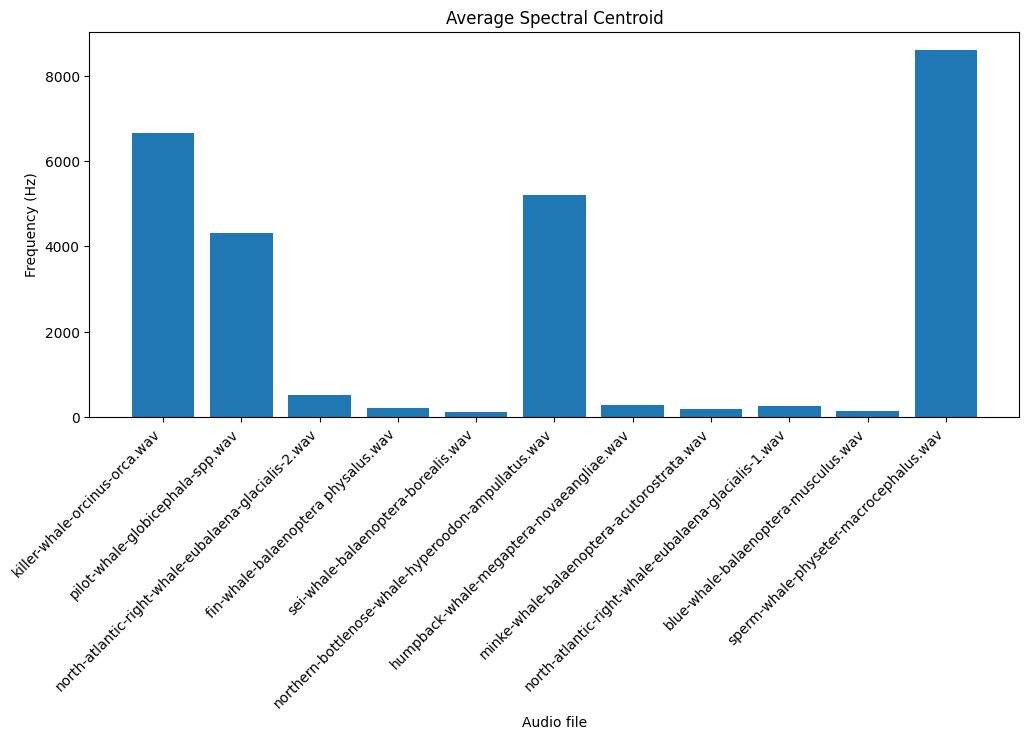

In [8]:
plt.figure(figsize=(12, 5))

plt.bar(
    df['file'],
    df['spectral_centroid_hz']
)

plt.title('Average Spectral Centroid')
plt.xlabel('Audio file')
plt.ylabel('Frequency (Hz)')
plt.xticks(rotation=45, ha='right')

plt.show()

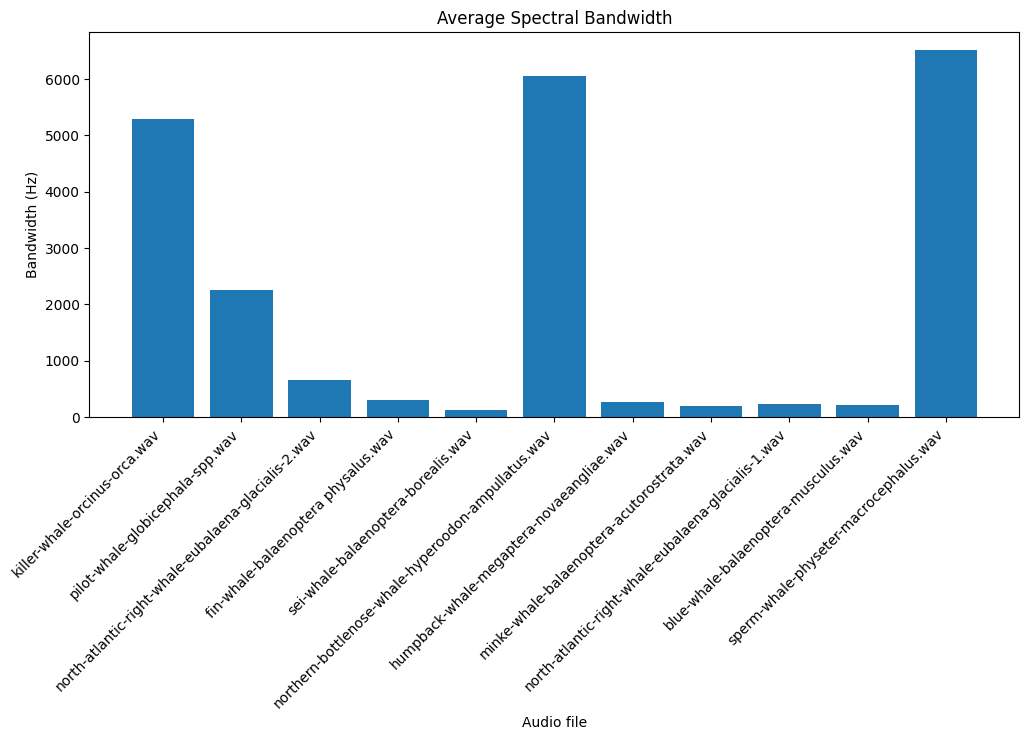

In [9]:
plt.figure(figsize=(12, 5))

plt.bar(
    df['file'],
    df['spectral_bandwidth_hz']
)

plt.title('Average Spectral Bandwidth')
plt.xlabel('Audio file')
plt.ylabel('Bandwidth (Hz)')
plt.xticks(rotation=45, ha='right')

plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

features = [
    'duration_sec',
    'rms',
    'spectral_centroid_hz',
    'spectral_bandwidth_hz'
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Размер данных:", X_scaled.shape)

Размер данных: (11, 4)


In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(X_scaled)

df[['file', 'cluster']]

,file,cluster
0,killer-whale-orcinus-orca.wav,1
1,pilot-whale-globicephala-spp.wav,2
2,north-atlantic-right-whale-eubalaena-glacialis...,2
3,fin-whale-balaenoptera physalus.wav,2
4,sei-whale-balaenoptera-borealis.wav,2
5,northern-bottlenose-whale-hyperoodon-ampullatu...,1
6,humpback-whale-megaptera-novaeangliae.wav,2
7,minke-whale-balaenoptera-acutorostrata.wav,2
8,north-atlantic-right-whale-eubalaena-glacialis...,2
9,blue-whale-balaenoptera-musculus.wav,0


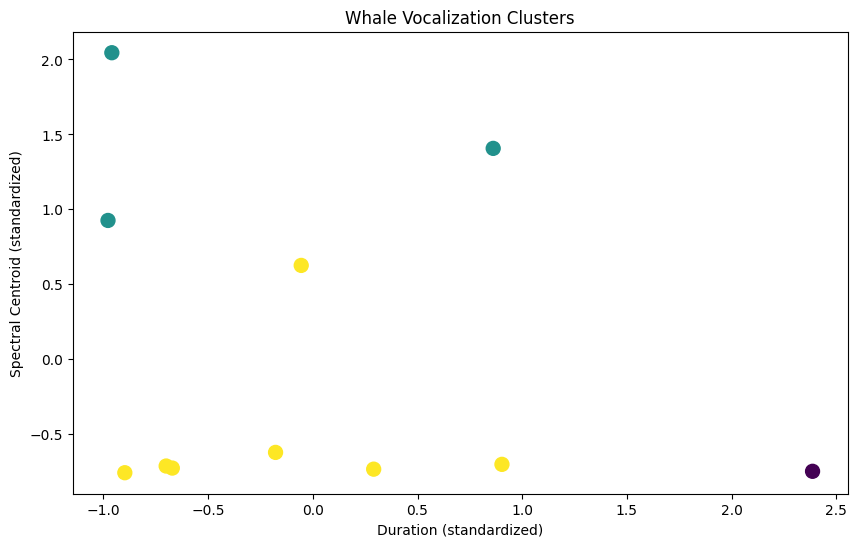

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 2],
    c=df['cluster'],
    s=100
)

plt.title('Whale Vocalization Clusters')
plt.xlabel('Duration (standardized)')
plt.ylabel('Spectral Centroid (standardized)')

plt.show()

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Размер после PCA:", X_pca.shape)
print("Объяснённая дисперсия:", pca.explained_variance_ratio_)
print("Всего объяснено:",
      round(sum(pca.explained_variance_ratio_) * 100, 2), "%")

Размер после PCA: (11, 2)
Объяснённая дисперсия: [0.64494568 0.26590418]
Всего объяснено: 91.08 %


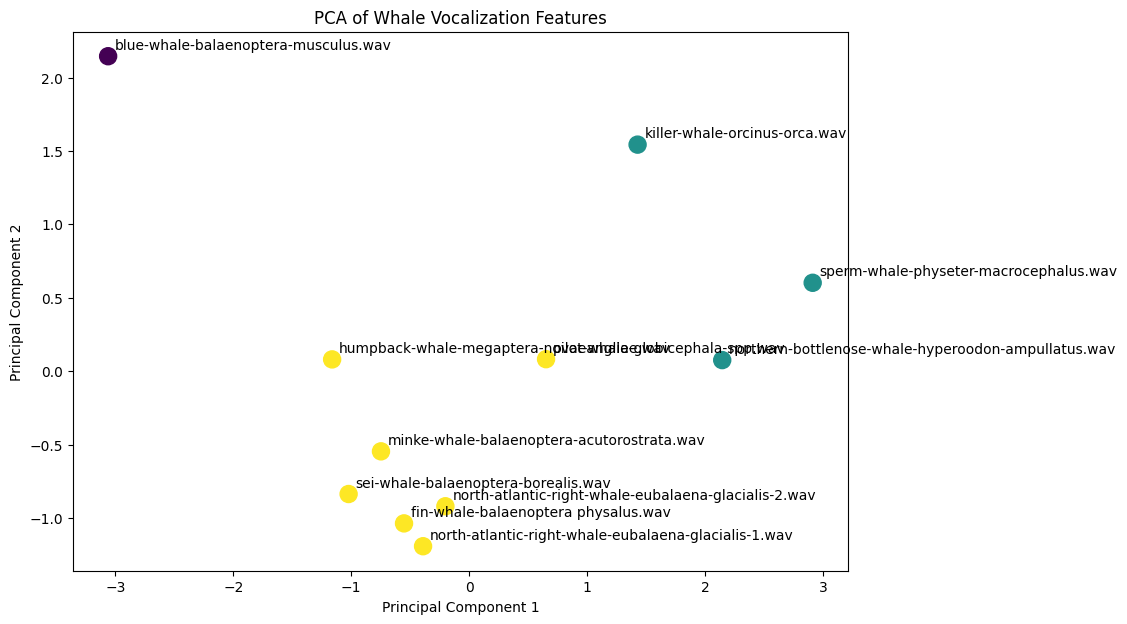

In [14]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    s=150
)

for i, file in enumerate(df['file']):
    plt.annotate(
        file,
        (X_pca[i, 0], X_pca[i, 1]),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('PCA of Whale Vocalization Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [15]:
cluster_summary = df.groupby('cluster')[
    [
        'duration_sec',
        'rms',
        'spectral_centroid_hz',
        'spectral_bandwidth_hz'
    ]
].mean()

cluster_summary

,duration_sec,rms,spectral_centroid_hz,spectral_bandwidth_hz
cluster,,,,
0,92.966000,0.229368,142.680400,208.987359
1,21.923878,0.020691,6830.262689,5950.697449
2,26.371534,0.057755,838.696062,573.253872


In [16]:
import librosa
import numpy as np

mfcc_results = []

for file in audio_files:

    file_path = '/content/' + file

    y, sr = librosa.load(file_path, sr=None)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )


    mfcc_mean = np.mean(mfcc, axis=1)

    mfcc_results.append(mfcc_mean)

mfcc_array = np.array(mfcc_results)

print("Размер MFCC данных:", mfcc_array.shape)

Размер MFCC данных: (11, 13)


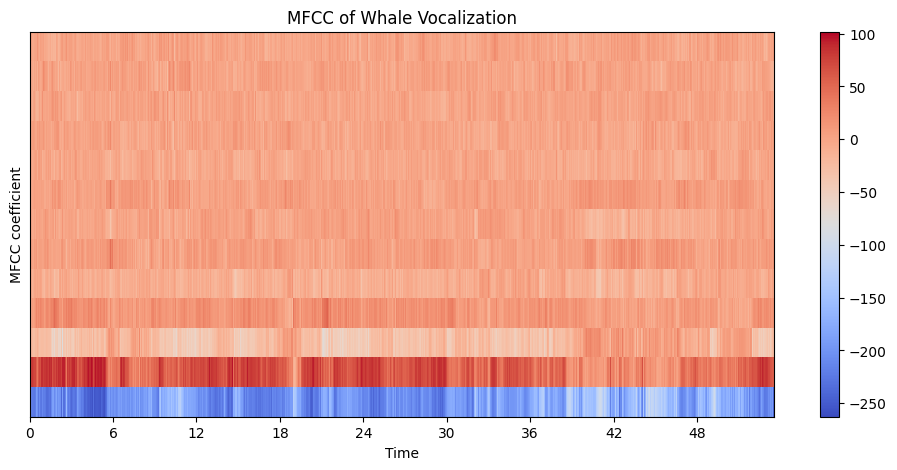

In [17]:
file_path = '/content/' + audio_files[0]

y, sr = librosa.load(file_path, sr=None)

mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mfcc,
    x_axis='time',
    sr=sr
)

plt.colorbar()

plt.title('MFCC of Whale Vocalization')
plt.ylabel('MFCC coefficient')

plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler

scaler_mfcc = StandardScaler()

X_mfcc_scaled = scaler_mfcc.fit_transform(mfcc_array)

print(X_mfcc_scaled.shape)

(11, 13)


In [19]:
from sklearn.cluster import KMeans

kmeans_mfcc = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

mfcc_clusters = kmeans_mfcc.fit_predict(X_mfcc_scaled)

df['mfcc_cluster'] = mfcc_clusters

df[['file', 'cluster', 'mfcc_cluster']]

,file,cluster,mfcc_cluster
0,killer-whale-orcinus-orca.wav,1,1
1,pilot-whale-globicephala-spp.wav,2,2
2,north-atlantic-right-whale-eubalaena-glacialis...,2,1
3,fin-whale-balaenoptera physalus.wav,2,1
4,sei-whale-balaenoptera-borealis.wav,2,1
5,northern-bottlenose-whale-hyperoodon-ampullatu...,1,1
6,humpback-whale-megaptera-novaeangliae.wav,2,1
7,minke-whale-balaenoptera-acutorostrata.wav,2,0
8,north-atlantic-right-whale-eubalaena-glacialis...,2,0
9,blue-whale-balaenoptera-musculus.wav,0,1


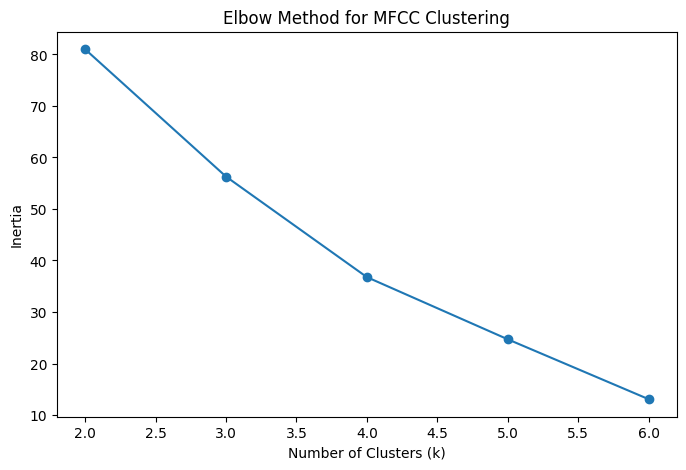

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_mfcc_scaled)

    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 7),
    inertias,
    marker='o'
)

plt.title('Elbow Method for MFCC Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.show()

In [21]:
from sklearn.decomposition import PCA

pca_mfcc = PCA(n_components=2)

X_mfcc_pca = pca_mfcc.fit_transform(X_mfcc_scaled)

print("Размер:", X_mfcc_pca.shape)
print(
    "Объяснено:",
    round(sum(pca_mfcc.explained_variance_ratio_) * 100, 2),
    "%"
)

Размер: (11, 2)
Объяснено: 69.34 %


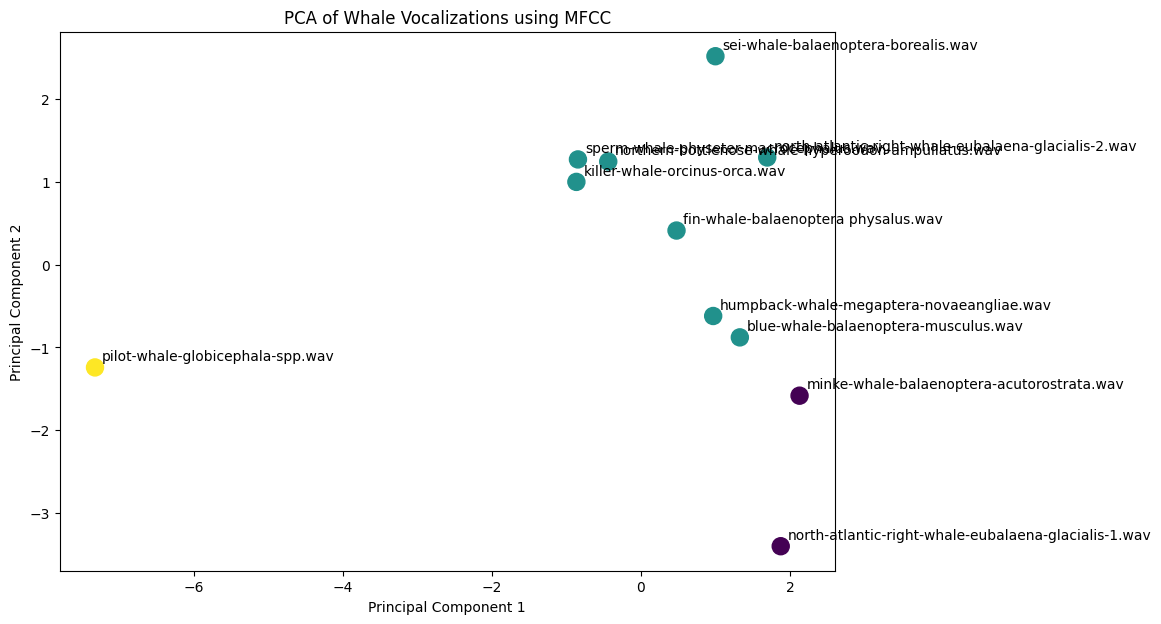

In [22]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_mfcc_pca[:, 0],
    X_mfcc_pca[:, 1],
    c=df['mfcc_cluster'],
    s=150
)

for i, file in enumerate(df['file']):
    plt.annotate(
        file,
        (X_mfcc_pca[i, 0], X_mfcc_pca[i, 1]),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('PCA of Whale Vocalizations using MFCC')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [23]:
import librosa
import numpy as np

segments = []

segment_duration = 5  # секунд

for file in audio_files:

    file_path = '/content/' + file

    y, sr = librosa.load(file_path, sr=None)

    segment_length = int(segment_duration * sr)

    for start in range(0, len(y), segment_length):

        end = start + segment_length

        segment = y[start:end]

        # Берём только полноценные 5-секундные фрагменты
        if len(segment) == segment_length:

            segments.append({
                'file': file,
                'audio': segment,
                'sr': sr
            })

print("Всего 5-секундных фрагментов:", len(segments))

Всего 5-секундных фрагментов: 62


In [24]:
segment_features = []

for segment_data in segments:

    y = segment_data['audio']
    sr = segment_data['sr']

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    mfcc_mean = np.mean(mfcc, axis=1)

    segment_features.append(mfcc_mean)

segment_features = np.array(segment_features)

print("Размер:", segment_features.shape)

Размер: (62, 13)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler_segments = StandardScaler()

X_segments_scaled = scaler_segments.fit_transform(
    segment_features
)

print("Размер:", X_segments_scaled.shape)

Размер: (62, 13)


In [26]:
from sklearn.cluster import KMeans

kmeans_segments = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

segment_clusters = kmeans_segments.fit_predict(
    X_segments_scaled
)

print("Кластеры:", segment_clusters)

Кластеры: [0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]


In [27]:
from sklearn.decomposition import PCA

pca_segments = PCA(n_components=2)

X_segments_pca = pca_segments.fit_transform(
    X_segments_scaled
)

print(
    "Объяснено:",
    round(
        sum(pca_segments.explained_variance_ratio_) * 100,
        2
    ),
    "%"
)

Объяснено: 71.34 %


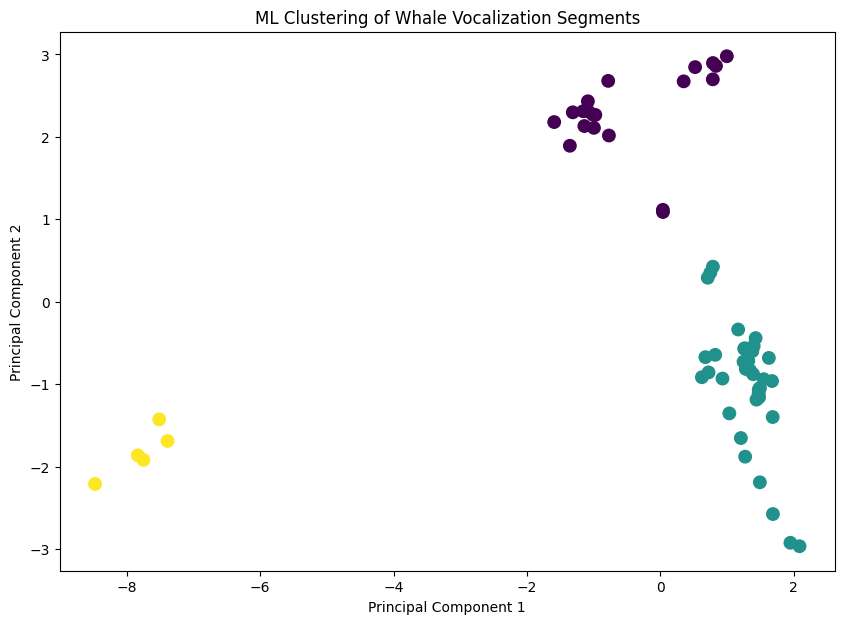

In [28]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_segments_pca[:, 0],
    X_segments_pca[:, 1],
    c=segment_clusters,
    s=80
)

plt.title('ML Clustering of Whale Vocalization Segments')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [29]:
import pandas as pd

segment_info = pd.DataFrame({
    'file': [s['file'] for s in segments],
    'cluster': segment_clusters
})

segment_info

,file,cluster
0,killer-whale-orcinus-orca.wav,0
1,killer-whale-orcinus-orca.wav,0
2,killer-whale-orcinus-orca.wav,0
3,killer-whale-orcinus-orca.wav,0
4,killer-whale-orcinus-orca.wav,0
...,...,...
57,blue-whale-balaenoptera-musculus.wav,1
58,blue-whale-balaenoptera-musculus.wav,1
59,blue-whale-balaenoptera-musculus.wav,1
60,blue-whale-balaenoptera-musculus.wav,1


In [30]:
cluster_distribution = pd.crosstab(
    segment_info['file'],
    segment_info['cluster']
)

cluster_distribution

cluster,0,1,2
file,,,
blue-whale-balaenoptera-musculus.wav,0,18,0
fin-whale-balaenoptera physalus.wav,2,0,0
humpback-whale-megaptera-novaeangliae.wav,0,10,0
killer-whale-orcinus-orca.wav,10,0,0
minke-whale-balaenoptera-acutorostrata.wav,0,7,0
north-atlantic-right-whale-eubalaena-glacialis-1.wav,0,2,0
north-atlantic-right-whale-eubalaena-glacialis-2.wav,5,0,0
northern-bottlenose-whale-hyperoodon-ampullatus.wav,1,0,0
pilot-whale-globicephala-spp.wav,0,0,5


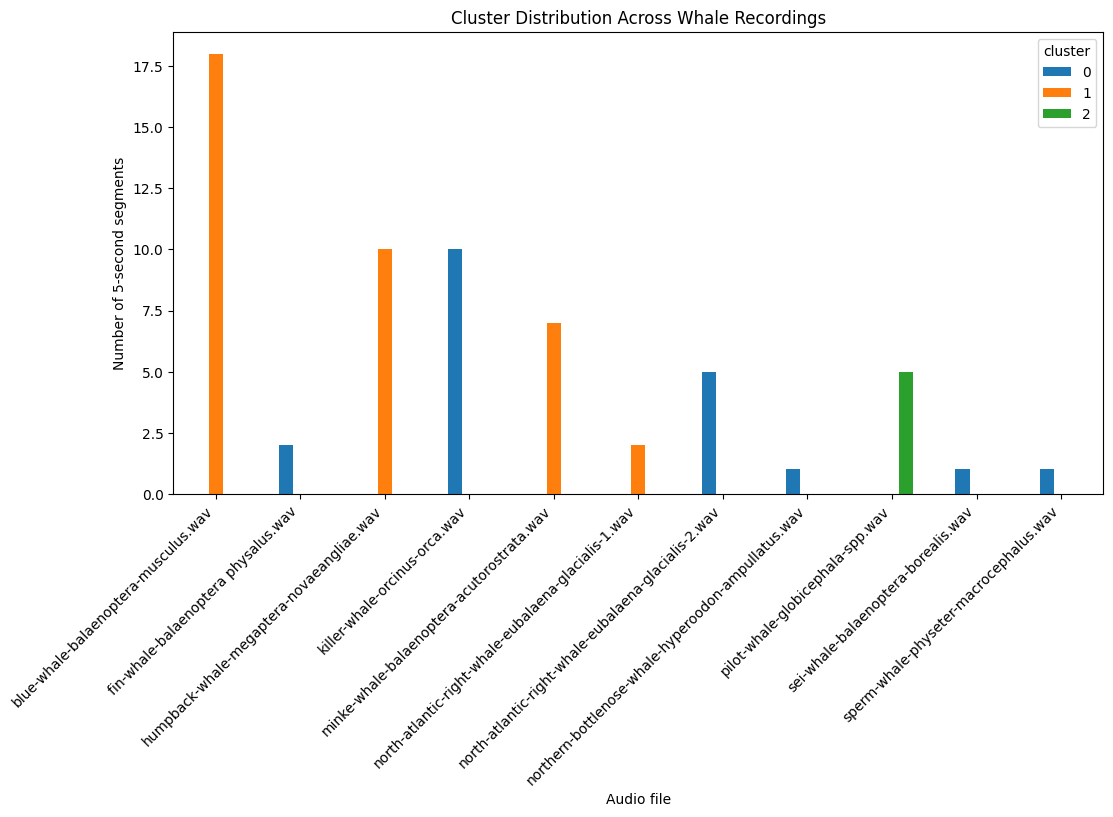

In [31]:
cluster_distribution.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Cluster Distribution Across Whale Recordings')
plt.xlabel('Audio file')
plt.ylabel('Number of 5-second segments')
plt.xticks(rotation=45, ha='right')

plt.show()

In [32]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_segments_scaled,
    segment_clusters
)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.46


In [33]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []

K = range(2, 6)

for k in K:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_segments_scaled)

    score = silhouette_score(
        X_segments_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"k = {k}: Silhouette Score = {score:.3f}")

k = 2: Silhouette Score = 0.621
k = 3: Silhouette Score = 0.460
k = 4: Silhouette Score = 0.416
k = 5: Silhouette Score = 0.466


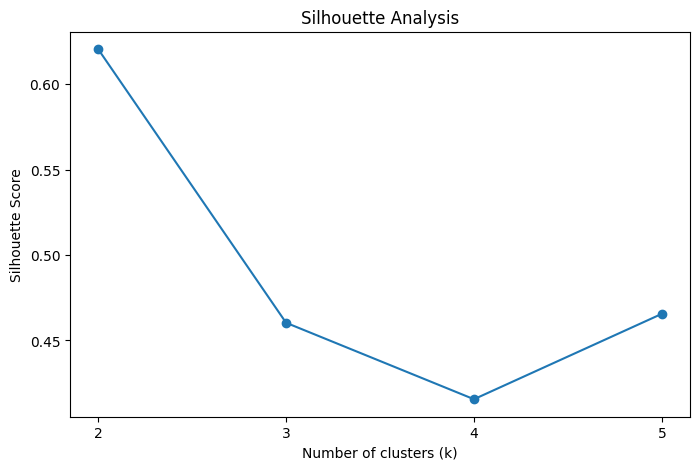

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    K,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.xticks(list(K))
plt.show()

In [35]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

final_clusters = kmeans_final.fit_predict(
    X_segments_scaled
)

print("Кластеры:", final_clusters)

Кластеры: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [36]:
segment_info['final_cluster'] = final_clusters

segment_info.head(10)

,file,cluster,final_cluster
0,killer-whale-orcinus-orca.wav,0,0
1,killer-whale-orcinus-orca.wav,0,0
2,killer-whale-orcinus-orca.wav,0,0
3,killer-whale-orcinus-orca.wav,0,0
4,killer-whale-orcinus-orca.wav,0,0
5,killer-whale-orcinus-orca.wav,0,0
6,killer-whale-orcinus-orca.wav,0,0
7,killer-whale-orcinus-orca.wav,0,0
8,killer-whale-orcinus-orca.wav,0,0
9,killer-whale-orcinus-orca.wav,0,0


In [37]:
final_distribution = pd.crosstab(
    segment_info['file'],
    segment_info['final_cluster']
)

final_distribution

final_cluster,0,1
file,,
blue-whale-balaenoptera-musculus.wav,18,0
fin-whale-balaenoptera physalus.wav,2,0
humpback-whale-megaptera-novaeangliae.wav,10,0
killer-whale-orcinus-orca.wav,10,0
minke-whale-balaenoptera-acutorostrata.wav,7,0
north-atlantic-right-whale-eubalaena-glacialis-1.wav,2,0
north-atlantic-right-whale-eubalaena-glacialis-2.wav,5,0
northern-bottlenose-whale-hyperoodon-ampullatus.wav,1,0
pilot-whale-globicephala-spp.wav,0,5


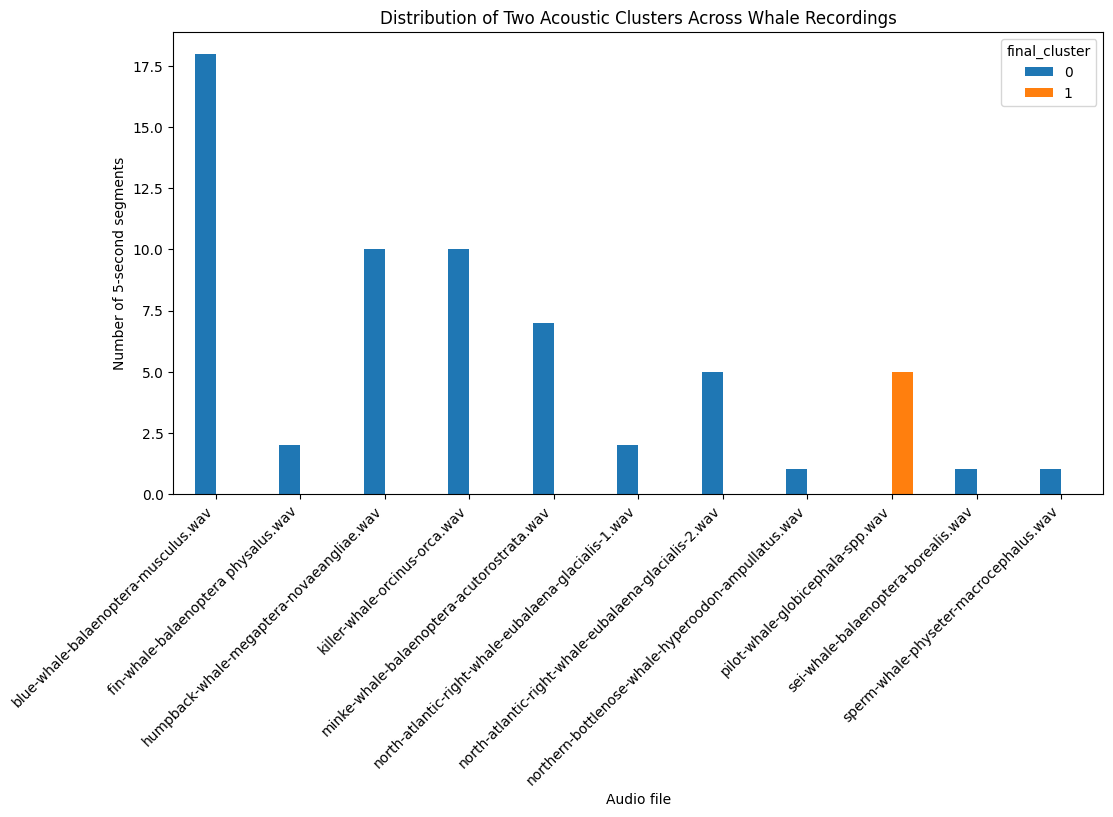

In [38]:
final_distribution.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Distribution of Two Acoustic Clusters Across Whale Recordings')
plt.xlabel('Audio file')
plt.ylabel('Number of 5-second segments')
plt.xticks(rotation=45, ha='right')
plt.show()

In [39]:
cluster_features = pd.DataFrame(
    X_segments_scaled,
    columns=[f'MFCC_{i+1}' for i in range(13)]
)

cluster_features['cluster'] = final_clusters

cluster_summary = cluster_features.groupby('cluster').mean()

cluster_summary

,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
cluster,,,,,,,,,,,,,
0,-0.109057,0.189886,0.192973,-0.067617,0.097281,-0.194508,0.178399,-0.254968,0.097315,-0.251772,0.264323,-0.229859,0.257180
1,1.243249,-2.164706,-2.199893,0.770837,-1.109001,2.217394,-2.033746,2.906634,-1.109397,2.870202,-3.013286,2.620398,-2.931852


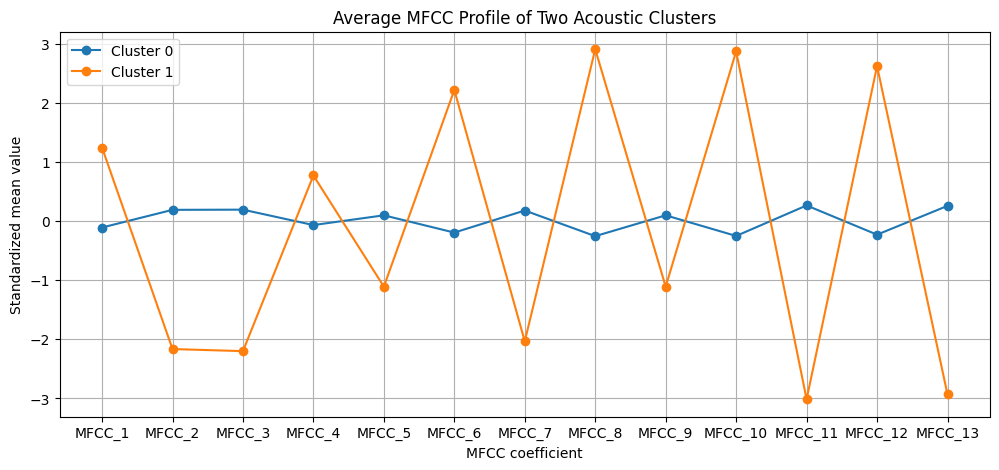

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(
    cluster_summary.columns,
    cluster_summary.loc[0],
    marker='o',
    label='Cluster 0'
)

plt.plot(
    cluster_summary.columns,
    cluster_summary.loc[1],
    marker='o',
    label='Cluster 1'
)

plt.title('Average MFCC Profile of Two Acoustic Clusters')
plt.xlabel('MFCC coefficient')
plt.ylabel('Standardized mean value')
plt.legend()
plt.grid(True)

plt.show()

In [41]:
cluster_0_files = segment_info[
    segment_info['final_cluster'] == 0
]

cluster_1_files = segment_info[
    segment_info['final_cluster'] == 1
]

print("Cluster 0:")
print(cluster_0_files.head())

print("\nCluster 1:")
print(cluster_1_files.head())

Cluster 0:
                            file  cluster  final_cluster
0  killer-whale-orcinus-orca.wav        0              0
1  killer-whale-orcinus-orca.wav        0              0
2  killer-whale-orcinus-orca.wav        0              0
3  killer-whale-orcinus-orca.wav        0              0
4  killer-whale-orcinus-orca.wav        0              0

Cluster 1:
                                file  cluster  final_cluster
10  pilot-whale-globicephala-spp.wav        2              1
11  pilot-whale-globicephala-spp.wav        2              1
12  pilot-whale-globicephala-spp.wav        2              1
13  pilot-whale-globicephala-spp.wav        2              1
14  pilot-whale-globicephala-spp.wav        2              1


In [42]:
print(len(segments))

62


In [43]:
idx_cluster_0 = np.where(final_clusters == 0)[0][0]
idx_cluster_1 = np.where(final_clusters == 1)[0][0]

print("Пример Cluster 0:")
print("Segment:", idx_cluster_0)
print("Source file:", segments[idx_cluster_0]['file'])

print("\nПример Cluster 1:")
print("Segment:", idx_cluster_1)
print("Source file:", segments[idx_cluster_1]['file'])

Пример Cluster 0:
Segment: 0
Source file: killer-whale-orcinus-orca.wav

Пример Cluster 1:
Segment: 10
Source file: pilot-whale-globicephala-spp.wav


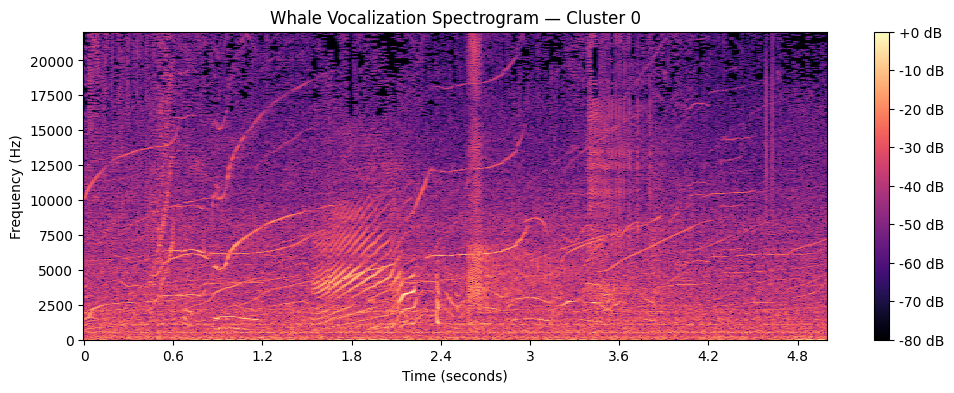

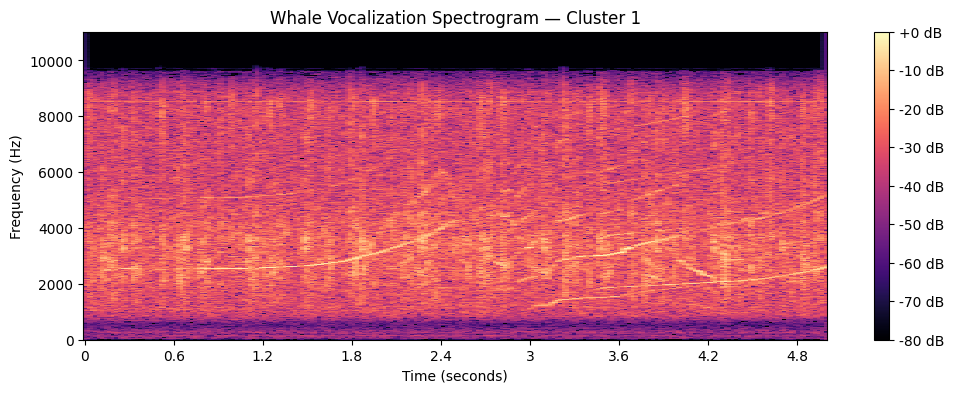

In [44]:
for cluster_id, idx in [(0, idx_cluster_0), (1, idx_cluster_1)]:

    y = segments[idx]['audio']
    sr = segments[idx]['sr']

    S = librosa.amplitude_to_db(
        np.abs(librosa.stft(y)),
        ref=np.max
    )

    plt.figure(figsize=(12, 4))

    librosa.display.specshow(
        S,
        sr=sr,
        x_axis='time',
        y_axis='hz'
    )

    plt.colorbar(format='%+2.0f dB')

    plt.title(
        f'Whale Vocalization Spectrogram — Cluster {cluster_id}'
    )

    plt.xlabel('Time (seconds)')
    plt.ylabel('Frequency (Hz)')

    plt.show()

In [45]:
from IPython.display import Audio, display

print("Cluster 0:")
display(
    Audio(
        segments[idx_cluster_0]['audio'],
        rate=segments[idx_cluster_0]['sr']
    )
)

print("Cluster 1:")
display(
    Audio(
        segments[idx_cluster_1]['audio'],
        rate=segments[idx_cluster_1]['sr']
    )
)

Cluster 0:


Cluster 1:


In [46]:
import librosa
import numpy as np

TARGET_SR = 22050
SEGMENT_DURATION = 5

segments_normalized = []

for file in audio_files:
    file_path = '/content/' + file

    # Все записи загружаются с одинаковым sample rate
    y, sr = librosa.load(
        file_path,
        sr=TARGET_SR
    )

    segment_length = SEGMENT_DURATION * sr

    for start in range(0, len(y), segment_length):
        end = start + segment_length
        segment = y[start:end]

        # Берём только полные 5-секундные фрагменты
        if len(segment) == segment_length:
            segments_normalized.append({
                'file': file,
                'audio': segment,
                'sr': sr
            })

print("Количество сегментов:", len(segments_normalized))
print("Sample rate:", TARGET_SR)

Количество сегментов: 62
Sample rate: 22050


In [47]:
normalized_features = []

for segment_data in segments_normalized:

    y = segment_data['audio']
    sr = segment_data['sr']

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    mfcc_mean = np.mean(mfcc, axis=1)
    normalized_features.append(mfcc_mean)

normalized_features = np.array(normalized_features)

print("Размер MFCC:", normalized_features.shape)

Размер MFCC: (62, 13)


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Нормализуем MFCC-признаки
scaler_normalized = StandardScaler()

X_normalized_scaled = scaler_normalized.fit_transform(
    normalized_features
)

# Проверяем разное количество кластеров
for k in range(2, 6):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_normalized_scaled)

    score = silhouette_score(
        X_normalized_scaled,
        labels
    )

    print(
        f"k = {k}: Silhouette Score = {score:.3f}"
    )

k = 2: Silhouette Score = 0.603
k = 3: Silhouette Score = 0.521
k = 4: Silhouette Score = 0.597
k = 5: Silhouette Score = 0.573


In [49]:
final_model_normalized = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

final_labels_normalized = final_model_normalized.fit_predict(
    X_normalized_scaled
)

final_score = silhouette_score(
    X_normalized_scaled,
    final_labels_normalized
)

print("Final Silhouette Score:", round(final_score, 3))
print("Cluster 0:", np.sum(final_labels_normalized == 0), "segments")
print("Cluster 1:", np.sum(final_labels_normalized == 1), "segments")

Final Silhouette Score: 0.603
Cluster 0: 57 segments
Cluster 1: 5 segments


In [50]:
normalized_segment_info = pd.DataFrame({
    'file': [s['file'] for s in segments_normalized],
    'cluster': final_labels_normalized
})

normalized_distribution = pd.crosstab(
    normalized_segment_info['file'],
    normalized_segment_info['cluster']
)

normalized_distribution

cluster,0,1
file,,
blue-whale-balaenoptera-musculus.wav,18,0
fin-whale-balaenoptera physalus.wav,2,0
humpback-whale-megaptera-novaeangliae.wav,10,0
killer-whale-orcinus-orca.wav,10,0
minke-whale-balaenoptera-acutorostrata.wav,7,0
north-atlantic-right-whale-eubalaena-glacialis-1.wav,2,0
north-atlantic-right-whale-eubalaena-glacialis-2.wav,5,0
northern-bottlenose-whale-hyperoodon-ampullatus.wav,1,0
pilot-whale-globicephala-spp.wav,0,5


In [51]:
# Убираем сегменты pilot whale
mask = normalized_segment_info['file'] != 'pilot-whale-globicephala-spp.wav'

X_without_pilot = X_normalized_scaled[mask.values]

print("Сегментов без pilot whale:", len(X_without_pilot))

Сегментов без pilot whale: 57


In [52]:
for k in range(2, 6):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_without_pilot)

    score = silhouette_score(
        X_without_pilot,
        labels
    )

    print(
        f"k = {k}: Silhouette Score = {score:.3f}"
    )

k = 2: Silhouette Score = 0.491
k = 3: Silhouette Score = 0.574
k = 4: Silhouette Score = 0.548
k = 5: Silhouette Score = 0.521


In [53]:
model_without_pilot = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_without_pilot = model_without_pilot.fit_predict(
    X_without_pilot
)

print("Cluster 0:", np.sum(labels_without_pilot == 0))
print("Cluster 1:", np.sum(labels_without_pilot == 1))
print("Cluster 2:", np.sum(labels_without_pilot == 2))

Cluster 0: 37
Cluster 1: 15
Cluster 2: 5


In [54]:
info_without_pilot = normalized_segment_info[
    mask
].copy()

info_without_pilot['new_cluster'] = labels_without_pilot

distribution_without_pilot = pd.crosstab(
    info_without_pilot['file'],
    info_without_pilot['new_cluster']
)

distribution_without_pilot

new_cluster,0,1,2
file,,,
blue-whale-balaenoptera-musculus.wav,18,0,0
fin-whale-balaenoptera physalus.wav,0,2,0
humpback-whale-megaptera-novaeangliae.wav,10,0,0
killer-whale-orcinus-orca.wav,0,10,0
minke-whale-balaenoptera-acutorostrata.wav,7,0,0
north-atlantic-right-whale-eubalaena-glacialis-1.wav,2,0,0
north-atlantic-right-whale-eubalaena-glacialis-2.wav,0,0,5
northern-bottlenose-whale-hyperoodon-ampullatus.wav,0,1,0
sei-whale-balaenoptera-borealis.wav,0,1,0


In [55]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_final = PCA(n_components=2)

X_final_pca = pca_final.fit_transform(
    X_without_pilot
)

print(
    "Explained variance:",
    round(
        sum(pca_final.explained_variance_ratio_) * 100,
        2
    ),
    "%"
)

Explained variance: 69.47 %


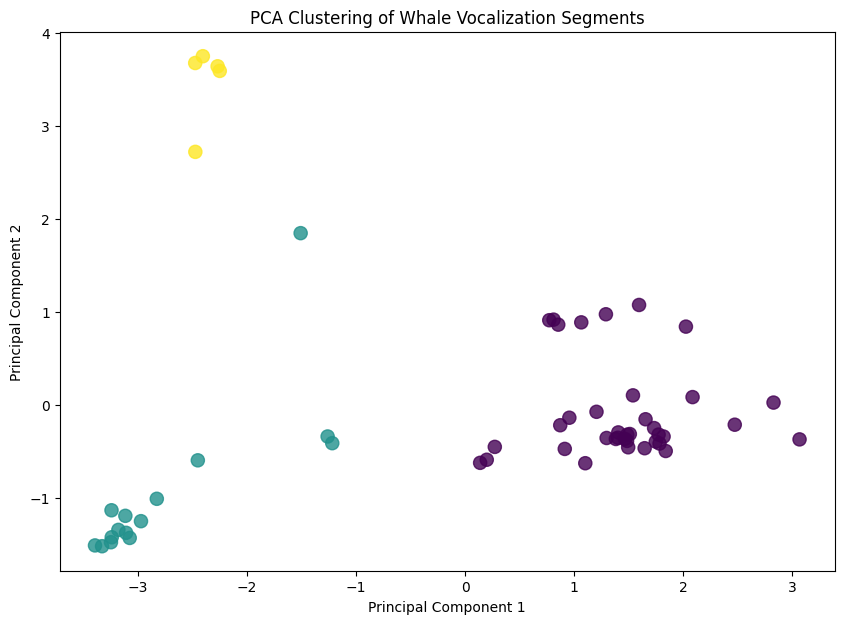

In [56]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_final_pca[:, 0],
    X_final_pca[:, 1],
    c=labels_without_pilot,
    s=90,
    alpha=0.8
)

plt.title(
    'PCA Clustering of Whale Vocalization Segments'
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [57]:

final_results = (
    info_without_pilot
    .groupby(['file', 'new_cluster'])
    .size()
    .reset_index(name='segments')
)

final_results = final_results.sort_values(
    ['new_cluster', 'file']
)

final_results

,file,new_cluster,segments
0,blue-whale-balaenoptera-musculus.wav,0,18
2,humpback-whale-megaptera-novaeangliae.wav,0,10
4,minke-whale-balaenoptera-acutorostrata.wav,0,7
5,north-atlantic-right-whale-eubalaena-glacialis...,0,2
1,fin-whale-balaenoptera physalus.wav,1,2
3,killer-whale-orcinus-orca.wav,1,10
7,northern-bottlenose-whale-hyperoodon-ampullatu...,1,1
8,sei-whale-balaenoptera-borealis.wav,1,1
9,sperm-whale-physeter-macrocephalus.wav,1,1
6,north-atlantic-right-whale-eubalaena-glacialis...,2,5


In [58]:

final_results.to_csv(
    '/content/whale_clustering_results.csv',
    index=False
)

print("Saved: whale_clustering_results.csv")

Saved: whale_clustering_results.csv


# 🐋 AI-Assisted Acoustic Analysis of Whale Vocalizations

### Unsupervised Machine Learning for Exploring Acoustic Patterns in Whale Sounds

**Project Goal:**  
This project explores whether machine learning can identify acoustic patterns in whale vocalizations without using predefined labels.

The system processes whale audio recordings, converts them into acoustic features using MFCCs (Mel-Frequency Cepstral Coefficients), and applies unsupervised machine learning to group acoustically similar recordings.

## Research Question

**Can unsupervised machine learning identify meaningful acoustic structure in whale vocalization recordings based only on their acoustic features?**

## Dataset

The dataset contains recordings from multiple whale species. Audio recordings are divided into 5-second segments and resampled to a common sample rate of 22,050 Hz to reduce technical differences between recordings.

## Methodology

The analysis pipeline consists of the following steps:

1. Load whale vocalization recordings.
2. Resample all recordings to 22,050 Hz.
3. Divide recordings into 5-second audio segments.
4. Extract 13 MFCC acoustic features from each segment.
5. Standardize the extracted features.
6. Apply K-Means clustering.
7. Evaluate different cluster counts using the Silhouette Score.
8. Use PCA to visualize the high-dimensional acoustic feature space.
9. Investigate potential outliers and repeat the clustering analysis.

## Results

The original dataset produced 62 five-second audio segments. MFCC features were extracted from each segment and used for unsupervised K-Means clustering.

### Initial Clustering

The initial analysis suggested that two clusters provided the strongest separation, with a Silhouette Score of **0.621**.

After resampling all recordings to a common sample rate of 22,050 Hz, the two-cluster solution remained strong with a Silhouette Score of **0.603**. This suggests that the observed acoustic separation was not caused solely by differences in sample rate.

### Outlier Investigation

Further analysis showed that all five segments from the pilot whale recording formed a separate cluster, while the remaining 57 segments were assigned to the other cluster.

Because this single recording strongly influenced the clustering result, an additional exploratory analysis was performed without the pilot whale recording.

### Clustering Without the Pilot Whale Recording

Among the remaining 57 segments, three clusters produced the highest Silhouette Score of **0.574**.

The resulting clusters showed clear separation in the MFCC feature space. PCA was used to reduce the 13-dimensional MFCC features to two dimensions for visualization.

The analysis also showed that segments from the same source recording tended to remain in the same cluster, suggesting that the model captures strong recording- or species-level acoustic differences.

## Limitations

This project is an exploratory analysis and has several important limitations.

- The dataset contains only 11 source recordings, so the results cannot be generalized to whale vocalizations as a whole.
- The 62 audio segments are not 62 independent recordings because multiple segments originate from the same source files.
- K-Means identifies acoustic similarity but does not determine the biological meaning of whale sounds.
- Differences between recordings may be influenced by species, recording conditions, background noise, equipment, or other environmental factors.
- The pilot whale recording behaved as a strong acoustic outlier, demonstrating how individual recordings can influence clustering results.

Therefore, the discovered clusters should be interpreted as groups of acoustically similar audio segments rather than distinct whale calls, behaviors, or forms of communication.

## Conclusion

This project demonstrated how unsupervised machine learning can be used to explore acoustic structure in whale vocalization recordings.

Whale audio was divided into 5-second segments, resampled to 22,050 Hz, represented using 13 MFCC features, standardized, and analyzed using K-Means clustering.

The initial clustering achieved a Silhouette Score of 0.621. After controlling for differences in sample rate, the strongest two-cluster solution achieved a score of 0.603.

Further investigation revealed that the pilot whale recording formed a strong acoustic outlier. After removing this recording for an additional exploratory analysis, the remaining 57 segments produced a three-cluster solution with a Silhouette Score of 0.574.

PCA visualization showed visible separation between these acoustic groups.

Overall, the experiment suggests that MFCC-based unsupervised learning can detect acoustic differences within a small collection of whale recordings. However, a larger and more carefully controlled dataset would be required to determine whether these patterns correspond to species, call types, behavior, recording conditions, or other factors.

### Future Work

Future versions of this project could:

- Analyze a much larger whale audio dataset.
- Compare MFCCs with log-Mel spectrogram features.
- Test additional clustering algorithms such as DBSCAN or hierarchical clustering.
- Use labeled datasets to train supervised whale-call classifiers.
- Investigate whether acoustic patterns remain consistent across different recordings of the same species.

---

### Technologies

Python • Librosa • NumPy • Pandas • Matplotlib • Scikit-learn

**Methods:** Audio Signal Processing • MFCC Feature Extraction • K-Means Clustering • Silhouette Analysis • PCA